In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [7]:
# Kaggle often has network restrictions, try this:
!pip install --no-cache-dir torch torchvision matplotlib seaborn scikit-learn pillow opencv-python
!pip install --no-cache-dir ultralytics
!pip install --no-cache-dir gdown

ERROR: Could not find a version that satisfies the requirement ultralytics (from versions: none)
ERROR: No matching distribution found for ultralytics


✅ Libraries imported successfully!

SETTING UP DATASET FROM KAGGLE...
✅ Found dataset at: /kaggle/input/datasets/iitmshubhamtiwari/final-dataset

Train folder exists: True
Val folder exists: True
Test folder exists: True

✅ Directories created:
   Base: /kaggle/working/training_output
   Checkpoints: /kaggle/working/training_output/checkpoints
   Models: /kaggle/working/training_output/models
   Plots: /kaggle/working/training_output/plots
   Logs: /kaggle/working/training_output/logs

Using device: cuda
GPU: Tesla T4
GPU Memory: 15.64 GB

LOADING DATASET...

CLASS MAPPING:
----------------------------------------
  0: other_activities
  1: safe_driving
  2: talking_phone
  3: texting_phone
  4: turning

Total classes: 5
Training samples: 5091
Validation samples: 1092
Test samples: 1093

✅ DataLoaders created successfully!
   - Train batches: 160
   - Val batches: 35
   - Test batches: 35

CREATING MODEL FROM SCRATCH...

Model: MobileNetV3 Large
Total parameters: 4,208,437
Trainable pa

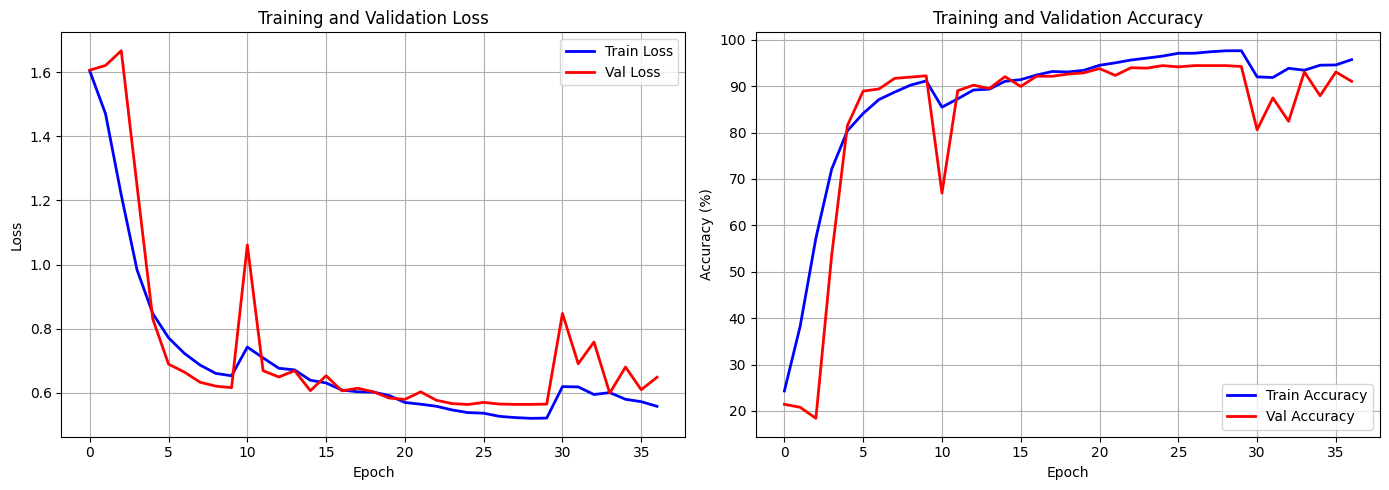

✅ Final training curves saved to: /kaggle/working/training_output/plots/final_training_curves.png

LOADING BEST MODEL FOR TESTING...
✅ Loaded best model from epoch 25 with Val Acc: 94.41%

TEST SET EVALUATION:

✅ Test Accuracy: 93.14%

Classification Report:
                  precision    recall  f1-score   support

other_activities       0.88      0.90      0.89       178
    safe_driving       0.90      0.93      0.91       252
   talking_phone       0.97      0.93      0.95       227
   texting_phone       0.99      0.97      0.98       235
         turning       0.91      0.93      0.92       201

        accuracy                           0.93      1093
       macro avg       0.93      0.93      0.93      1093
    weighted avg       0.93      0.93      0.93      1093



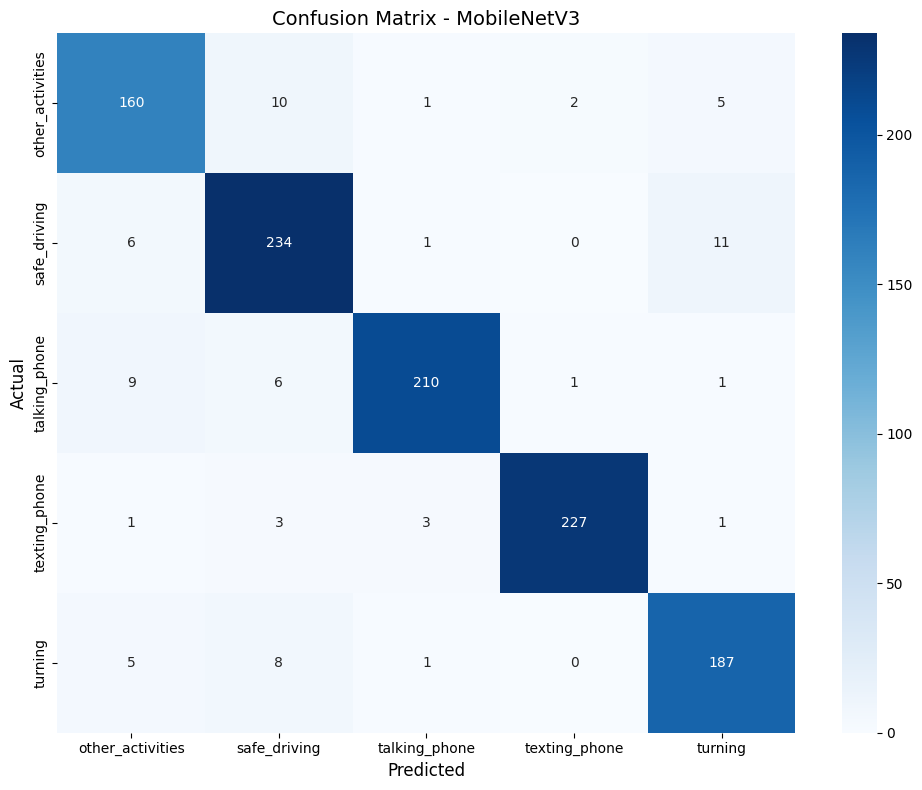


✅ Models saved to: /kaggle/working/training_output/models

MODEL TRAINING SUMMARY

Architecture: MobileNetV3 Large (From Scratch)
Input Shape: (3, 224, 224)
Output Classes: 5
Class Names: ['other_activities', 'safe_driving', 'talking_phone', 'texting_phone', 'turning']

Training Mode: From Scratch
Label Smoothing: 0.1

Dataset Split:
  - Training Samples: 5091
  - Validation Samples: 1092
  - Test Samples: 1093

Training Configuration:
  - Batch Size: 32
  - Learning Rate: 0.0003 (3e-4)
  - Weight Decay: 0.01
  - Optimizer: AdamW
  - Scheduler: CosineAnnealingWarmRestarts
  - Mixed Precision: True
  - Max Epochs: 80
  - Early Stopping Patience: 12

Results:
  - Best Validation Accuracy: 94.41%
  - Test Accuracy: 93.14%
  - Training Time: 11.77 minutes

FILES SAVED
Checkpoints: /kaggle/working/training_output/checkpoints
Models: /kaggle/working/training_output/models
Plots: /kaggle/working/training_output/plots
Logs: /kaggle/working/training_output/logs


📦 PREPARING FILES FOR DOWNLOAD

/kaggle/working/training_output.zip


🎉 TRAINING COMPLETE! 🎉

📁 All files saved to: /kaggle/working/training_output
📦 Download zip: /kaggle/working/training_output.zip


In [1]:
# ============================================
# MobileNetV3 Training Pipeline for Driver Activity Classification
# Features: 
#   - Train from scratch
#   - Checkpoint Resume (if training stops)
#   - Auto-download all files after training
#   - Organized folder structure
# ============================================

# ============================================
# 1. Install Required Libraries
# ============================================
!pip install -q torchvision matplotlib seaborn scikit-learn pillow opencv-python

# ============================================
# 2. Import Libraries
# ============================================
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import numpy as np
import os
import time
import json
import shutil
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from torch.cuda.amp import autocast, GradScaler
from torch.optim.lr_scheduler import CosineAnnealingLR, CosineAnnealingWarmRestarts
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

# ============================================
# 3. Setup Dataset from Kaggle Input
# ============================================
print("\n" + "="*60)
print("SETTING UP DATASET FROM KAGGLE...")
print("="*60)

# Check dataset location
data_dir = None

# Check possible locations
possible_paths = [
    '/kaggle/input/datasets/final_dataset',
    '/kaggle/input/final-dataset',
    '/kaggle/input/datasets/iitmshubhamtiwari/final-dataset',
    '/kaggle/input/iitmshubhamtiwari/final-dataset',
    '/kaggle/input/datasets',
]

for path in possible_paths:
    if os.path.exists(path):
        # Check if train/val/test exist
        if all(os.path.exists(os.path.join(path, f)) for f in ['train', 'val', 'test']):
            data_dir = path
            print(f"✅ Found dataset at: {data_dir}")
            break
        # Check subfolders
        for item in os.listdir(path):
            item_path = os.path.join(path, item)
            if os.path.isdir(item_path):
                if all(os.path.exists(os.path.join(item_path, f)) for f in ['train', 'val', 'test']):
                    data_dir = item_path
                    print(f"✅ Found dataset at: {data_dir}")
                    break
        if data_dir:
            break

if data_dir is None:
    print("\n❌ Could not find dataset!")
    print("\nPlease check your dataset path.")
    exit(1)

# Verify structure
train_dir = os.path.join(data_dir, 'train')
val_dir = os.path.join(data_dir, 'val')
test_dir = os.path.join(data_dir, 'test')

print(f"\nTrain folder exists: {os.path.exists(train_dir)}")
print(f"Val folder exists: {os.path.exists(val_dir)}")
print(f"Test folder exists: {os.path.exists(test_dir)}")

# ============================================
# 4. Configuration with Organized Folders
# ============================================
class Config:
    # Data paths
    data_dir = data_dir
    
    # Organized folder structure
    base_dir = '/kaggle/working/training_output'
    checkpoint_dir = os.path.join(base_dir, 'checkpoints')
    models_dir = os.path.join(base_dir, 'models')
    plots_dir = os.path.join(base_dir, 'plots')
    logs_dir = os.path.join(base_dir, 'logs')
    
    # Specific file paths
    checkpoint_path = os.path.join(checkpoint_dir, 'mobilenetv3_checkpoint.pth')
    best_model_path = os.path.join(models_dir, 'best_mobilenetv3.pth')
    final_model_path = os.path.join(models_dir, 'final_mobilenetv3.pth')
    full_model_path = os.path.join(models_dir, 'final_mobilenetv3_full.pth')
    
    # Training parameters
    batch_size = 32
    num_workers = 2
    epochs = 80
    learning_rate = 3e-4
    weight_decay = 0.01
    patience = 12
    label_smoothing = 0.1
    
    # Model parameters
    input_size = 224
    num_classes = 5
    
    # Mixed precision
    use_amp = True
    
    # Class names
    class_names = ['other_activities', 'safe_driving', 'talking_phone', 'texting_phone', 'turning']
    
    # Scheduler
    scheduler_type = 'cosine_warm_restarts'
    t_0 = 10
    t_mult = 2

# Create all directories
os.makedirs(Config.base_dir, exist_ok=True)
os.makedirs(Config.checkpoint_dir, exist_ok=True)
os.makedirs(Config.models_dir, exist_ok=True)
os.makedirs(Config.plots_dir, exist_ok=True)
os.makedirs(Config.logs_dir, exist_ok=True)

print(f"\n✅ Directories created:")
print(f"   Base: {Config.base_dir}")
print(f"   Checkpoints: {Config.checkpoint_dir}")
print(f"   Models: {Config.models_dir}")
print(f"   Plots: {Config.plots_dir}")
print(f"   Logs: {Config.logs_dir}")

# ============================================
# 5. Check for GPU
# ============================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")

if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# ============================================
# 6. Custom Dataset
# ============================================
class DriverActivityDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.dataset = datasets.ImageFolder(root=root_dir, transform=None)
        self.classes = self.dataset.classes
        self.class_to_idx = self.dataset.class_to_idx
        
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        img_path, label = self.dataset.imgs[idx]
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

# ============================================
# 7. Define Transforms
# ============================================
train_transform = transforms.Compose([
    transforms.Resize((Config.input_size, Config.input_size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((Config.input_size, Config.input_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ============================================
# 8. Load Dataset
# ============================================
print("\n" + "="*60)
print("LOADING DATASET...")
print("="*60)

train_dataset = DriverActivityDataset(root_dir=train_dir, transform=train_transform)
val_dataset = DriverActivityDataset(root_dir=val_dir, transform=val_transform)
test_dataset = DriverActivityDataset(root_dir=test_dir, transform=val_transform)

print("\nCLASS MAPPING:")
print("-"*40)
class_names = train_dataset.classes
for idx, class_name in enumerate(class_names):
    print(f"  {idx}: {class_name}")

num_classes = len(class_names)
print(f"\nTotal classes: {num_classes}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print("="*60 + "\n")

# ============================================
# 9. Create DataLoaders
# ============================================
train_loader = DataLoader(
    train_dataset,
    batch_size=Config.batch_size,
    shuffle=True,
    num_workers=Config.num_workers,
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=Config.batch_size,
    shuffle=False,
    num_workers=Config.num_workers,
    pin_memory=True if torch.cuda.is_available() else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=Config.batch_size,
    shuffle=False,
    num_workers=Config.num_workers,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"✅ DataLoaders created successfully!")
print(f"   - Train batches: {len(train_loader)}")
print(f"   - Val batches: {len(val_loader)}")
print(f"   - Test batches: {len(test_loader)}")

# ============================================
# 10. Create Model (From Scratch)
# ============================================
def create_model(num_classes, from_scratch=True):
    if from_scratch:
        print("\n" + "="*60)
        print("CREATING MODEL FROM SCRATCH...")
        print("="*60)
        model = models.mobilenet_v3_large(weights=None)
    else:
        print("\n" + "="*60)
        print("CREATING MODEL WITH PRETRAINED WEIGHTS...")
        print("="*60)
        model = models.mobilenet_v3_large(weights='IMAGENET1K_V1')
    
    model.classifier[3] = nn.Linear(in_features=1280, out_features=num_classes)
    return model

# Create model from scratch
model = create_model(num_classes, from_scratch=True)
model = model.to(device)

print(f"\nModel: MobileNetV3 Large")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Output classes: {num_classes}")

# ============================================
# 11. Label Smoothing Loss
# ============================================
class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1):
        super(LabelSmoothingCrossEntropy, self).__init__()
        self.smoothing = smoothing
        
    def forward(self, pred, target):
        n_classes = pred.size(1)
        one_hot = torch.zeros_like(pred).scatter(1, target.unsqueeze(1), 1)
        smooth_target = one_hot * (1 - self.smoothing) + (1 - one_hot) * self.smoothing / (n_classes - 1)
        loss = -torch.sum(smooth_target * torch.log_softmax(pred, dim=1), dim=1)
        return loss.mean()

criterion = LabelSmoothingCrossEntropy(smoothing=Config.label_smoothing)

# ============================================
# 12. Optimizer and Scheduler
# ============================================
optimizer = optim.AdamW(
    model.parameters(), 
    lr=Config.learning_rate,
    weight_decay=Config.weight_decay
)

scheduler = CosineAnnealingWarmRestarts(
    optimizer,
    T_0=Config.t_0,
    T_mult=Config.t_mult,
    eta_min=1e-6
)

scaler = GradScaler() if Config.use_amp else None

print(f"\nTraining Configuration:")
print(f"  - Model: MobileNetV3 Large (From Scratch)")
print(f"  - Optimizer: AdamW")
print(f"  - Learning Rate: {Config.learning_rate} (3e-4)")
print(f"  - Weight Decay: {Config.weight_decay}")
print(f"  - Scheduler: CosineAnnealingWarmRestarts")
print(f"  - Label Smoothing: {Config.label_smoothing}")
print(f"  - Mixed Precision: {Config.use_amp}")
print(f"  - Epochs: {Config.epochs}")
print(f"  - Early Stopping Patience: {Config.patience}")

# ============================================
# 13. Checkpoint Functions (Resume Support)
# ============================================
def save_checkpoint(epoch, model, optimizer, scheduler, scaler, 
                    train_losses, val_losses, train_accuracies, val_accuracies,
                    best_val_acc, is_best=False):
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'scaler_state_dict': scaler.state_dict() if scaler else None,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies,
        'best_val_acc': best_val_acc,
        'class_names': class_names,
        'num_classes': num_classes,
        'config': {
            'batch_size': Config.batch_size,
            'learning_rate': Config.learning_rate,
            'weight_decay': Config.weight_decay,
            'epochs': Config.epochs,
            'from_scratch': True,
            'label_smoothing': Config.label_smoothing,
            'scheduler_type': Config.scheduler_type
        }
    }
    
    # Save checkpoint
    torch.save(checkpoint, Config.checkpoint_path)
    print(f"  💾 Checkpoint saved at epoch {epoch+1}")
    
    # Save best model
    if is_best:
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'best_val_acc': best_val_acc,
            'class_names': class_names,
            'num_classes': num_classes
        }, Config.best_model_path)
        print(f"  ⭐ Best model saved with Val Acc: {best_val_acc:.2f}%")
    
    # Save metadata
    metadata = {
        'last_epoch': epoch,
        'best_val_acc': best_val_acc,
        'class_names': class_names,
        'num_classes': num_classes,
        'total_epochs': epoch + 1,
        'checkpoint_path': Config.checkpoint_path,
        'best_model_path': Config.best_model_path
    }
    with open(os.path.join(Config.logs_dir, 'training_metadata.json'), 'w') as f:
        json.dump(metadata, f, indent=4)

def load_checkpoint(model, optimizer, scheduler, scaler):
    if not os.path.exists(Config.checkpoint_path):
        print("ℹ️ No checkpoint found. Starting training from scratch.")
        return 0, [], [], [], [], 0.0
    
    print(f"\n🔄 Loading checkpoint from: {Config.checkpoint_path}")
    checkpoint = torch.load(Config.checkpoint_path, map_location=device)
    
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    
    if scaler and checkpoint['scaler_state_dict']:
        scaler.load_state_dict(checkpoint['scaler_state_dict'])
    
    start_epoch = checkpoint['epoch'] + 1
    train_losses = checkpoint.get('train_losses', [])
    val_losses = checkpoint.get('val_losses', [])
    train_accuracies = checkpoint.get('train_accuracies', [])
    val_accuracies = checkpoint.get('val_accuracies', [])
    best_val_acc = checkpoint.get('best_val_acc', 0.0)
    
    print(f"  ✅ Resuming from epoch {start_epoch}")
    print(f"  📊 Best Validation Accuracy so far: {best_val_acc:.2f}%")
    
    return start_epoch, train_losses, val_losses, train_accuracies, val_accuracies, best_val_acc

def resume_training():
    if os.path.exists(Config.checkpoint_path):
        print("\n" + "="*60)
        print("🔄 CHECKPOINT FOUND!")
        print("="*60)
        checkpoint = torch.load(Config.checkpoint_path, map_location=device)
        print(f"  Last completed epoch: {checkpoint['epoch'] + 1}")
        print(f"  Best validation accuracy: {checkpoint.get('best_val_acc', 0.0):.2f}%")
        
        response = input("\nDo you want to resume training from this checkpoint? (y/n): ")
        if response.lower() == 'y':
            return True
    
    return False

# ============================================
# 14. Training Loop with Resume Support
# ============================================
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, scaler):
    resume = resume_training()
    
    if resume:
        start_epoch, train_losses, val_losses, train_accuracies, val_accuracies, best_val_acc = load_checkpoint(
            model, optimizer, scheduler, scaler
        )
    else:
        if os.path.exists(Config.checkpoint_path):
            os.remove(Config.checkpoint_path)
            print("🗑️ Removed old checkpoint. Starting fresh training.")
        start_epoch = 0
        train_losses = []
        val_losses = []
        train_accuracies = []
        val_accuracies = []
        best_val_acc = 0.0
    
    early_stop_counter = 0
    
    print("\n" + "="*60)
    print("🚀 STARTING TRAINING...")
    print("="*60 + "\n")
    
    for epoch in range(start_epoch, Config.epochs):
        # Training Phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            
            if Config.use_amp and scaler:
                with autocast():
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            if (batch_idx + 1) % 10 == 0:
                print(f'Epoch {epoch+1}/{Config.epochs}, Batch {batch_idx+1}/{len(train_loader)}, Loss: {loss.item():.4f}')
        
        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        
        # Validation Phase
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        val_loss = val_loss / len(val_loader)
        val_acc = 100 * correct / total
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        
        scheduler.step()
        
        current_lr = optimizer.param_groups[0]['lr']
        print(f"\n{'='*60}")
        print(f"Epoch {epoch+1}/{Config.epochs}")
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
        print(f"Learning Rate: {current_lr:.6f}")
        print(f"{'='*60}\n")
        
        is_best = val_acc > best_val_acc
        if is_best:
            best_val_acc = val_acc
            early_stop_counter = 0
        else:
            early_stop_counter += 1
        
        # Save checkpoint after every epoch
        save_checkpoint(
            epoch, model, optimizer, scheduler, scaler,
            train_losses, val_losses, train_accuracies, val_accuracies,
            best_val_acc, is_best
        )
        
        # Save training history plot after each epoch
        save_training_plots(train_losses, val_losses, train_accuracies, val_accuracies, epoch)
        
        if early_stop_counter >= Config.patience:
            print(f"🛑 Early stopping triggered after {Config.patience} epochs without improvement.")
            break
    
    return train_losses, val_losses, train_accuracies, val_accuracies, best_val_acc

# ============================================
# 15. Save Training Plots
# ============================================
def save_training_plots(train_losses, val_losses, train_accuracies, val_accuracies, epoch):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1.plot(train_losses, label='Train Loss', color='blue', linewidth=2)
    ax1.plot(val_losses, label='Val Loss', color='red', linewidth=2)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training and Validation Loss', fontsize=12)
    ax1.legend()
    ax1.grid(True)
    
    ax2.plot(train_accuracies, label='Train Accuracy', color='blue', linewidth=2)
    ax2.plot(val_accuracies, label='Val Accuracy', color='red', linewidth=2)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Training and Validation Accuracy', fontsize=12)
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.savefig(os.path.join(Config.plots_dir, f'training_curves_epoch_{epoch+1}.png'), dpi=300)
    plt.close()

# ============================================
# 16. Download All Files to Local Machine
# ============================================
def download_all_files():
    """Create a zip file of all outputs and download."""
    print("\n" + "="*60)
    print("📦 PREPARING FILES FOR DOWNLOAD...")
    print("="*60)
    
    # Create zip file
    zip_path = '/kaggle/working/training_output.zip'
    shutil.make_archive(
        zip_path.replace('.zip', ''),
        'zip',
        Config.base_dir
    )
    
    print(f"✅ Files zipped to: {zip_path}")
    
    # List all files
    print("\n📁 Files included in zip:")
    print("-"*40)
    for root, dirs, files in os.walk(Config.base_dir):
        level = root.replace(Config.base_dir, '').count(os.sep)
        indent = ' ' * 2 * level
        print(f"{indent}{os.path.basename(root)}/")
        subindent = ' ' * 2 * (level + 1)
        for file in files:
            print(f"{subindent}{file}")
    
    print("\n" + "="*60)
    print("📥 DOWNLOAD YOUR FILES")
    print("="*60)
    print("\nClick the download button or run this command:")
    print(f"  from IPython.display import FileLink")
    print(f"  FileLink('{zip_path}')")
    print("="*60)
    
    return zip_path

# ============================================
# 17. Train the Model
# ============================================
start_time = time.time()

train_losses, val_losses, train_accuracies, val_accuracies, best_val_acc = train_model(
    model, train_loader, val_loader, criterion, optimizer, scheduler, scaler
)

end_time = time.time()
training_time = end_time - start_time
print(f"\n✅ Training completed in {training_time:.2f} seconds ({training_time/60:.2f} minutes)")

# ============================================
# 18. Save Final Training Plots
# ============================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label='Train Loss', color='blue', linewidth=2)
ax1.plot(val_losses, label='Val Loss', color='red', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss', fontsize=12)
ax1.legend()
ax1.grid(True)

ax2.plot(train_accuracies, label='Train Accuracy', color='blue', linewidth=2)
ax2.plot(val_accuracies, label='Val Accuracy', color='red', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Validation Accuracy', fontsize=12)
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(Config.plots_dir, 'final_training_curves.png'), dpi=300)
plt.show()

print(f"✅ Final training curves saved to: {Config.plots_dir}/final_training_curves.png")

# ============================================
# 19. Load Best Model for Testing
# ============================================
print("\n" + "="*60)
print("LOADING BEST MODEL FOR TESTING...")
print("="*60)

if os.path.exists(Config.best_model_path):
    checkpoint = torch.load(Config.best_model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"✅ Loaded best model from epoch {checkpoint['epoch']+1} with Val Acc: {checkpoint['best_val_acc']:.2f}%")
else:
    print("⚠️ Best model not found. Using current model.")
    
model.eval()

# ============================================
# 20. Evaluate on Test Set
# ============================================
print("\n" + "="*60)
print("TEST SET EVALUATION:")
print("="*60)

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

test_correct = sum(1 for p, l in zip(all_preds, all_labels) if p == l)
test_accuracy = 100 * test_correct / len(all_labels)

print(f"\n✅ Test Accuracy: {test_accuracy:.2f}%")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix - MobileNetV3', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(Config.plots_dir, 'confusion_matrix.png'), dpi=300)
plt.show()

# ============================================
# 21. Save Final Model
# ============================================
torch.save(model.state_dict(), Config.final_model_path)
torch.save(model, Config.full_model_path)

print(f"\n✅ Models saved to: {Config.models_dir}")

# ============================================
# 22. Save Summary Report
# ============================================
summary = f"""
================================================================================
MODEL TRAINING SUMMARY
================================================================================

Architecture: MobileNetV3 Large (From Scratch)
Input Shape: (3, {Config.input_size}, {Config.input_size})
Output Classes: {num_classes}
Class Names: {class_names}

Training Mode: From Scratch
Label Smoothing: {Config.label_smoothing}

Dataset Split:
  - Training Samples: {len(train_dataset)}
  - Validation Samples: {len(val_dataset)}
  - Test Samples: {len(test_dataset)}

Training Configuration:
  - Batch Size: {Config.batch_size}
  - Learning Rate: {Config.learning_rate} (3e-4)
  - Weight Decay: {Config.weight_decay}
  - Optimizer: AdamW
  - Scheduler: CosineAnnealingWarmRestarts
  - Mixed Precision: {Config.use_amp}
  - Max Epochs: {Config.epochs}
  - Early Stopping Patience: {Config.patience}

Results:
  - Best Validation Accuracy: {best_val_acc:.2f}%
  - Test Accuracy: {test_accuracy:.2f}%
  - Training Time: {training_time/60:.2f} minutes

================================================================================
FILES SAVED
================================================================================
Checkpoints: {Config.checkpoint_dir}
Models: {Config.models_dir}
Plots: {Config.plots_dir}
Logs: {Config.logs_dir}
================================================================================
"""

with open(os.path.join(Config.logs_dir, 'training_summary.txt'), 'w') as f:
    f.write(summary)

print(summary)

# ============================================
# 23. Download All Files
# ============================================
zip_path = download_all_files()

# Create download link
from IPython.display import FileLink
print("\n📥 Click the link below to download all files:")
display(FileLink(zip_path))

print("\n" + "="*60)
print("🎉 TRAINING COMPLETE! 🎉")
print("="*60)
print(f"\n📁 All files saved to: {Config.base_dir}")
print(f"📦 Download zip: {zip_path}")
print("="*60)

/tmp/ipykernel_58/3090827274.py:39: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3090827274.py:40: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.savefig('figure_3_4_hyperparameter_comparison.png', dpi=300, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


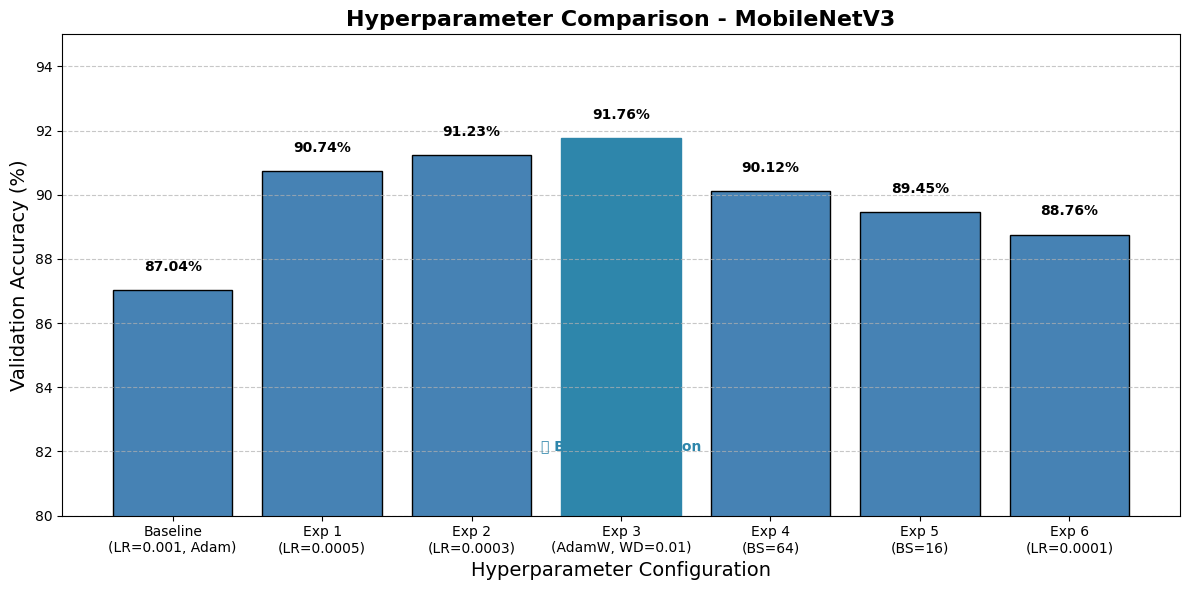

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Your hyperparameter experiment results
experiments = [
    'Baseline\n(LR=0.001, Adam)',
    'Exp 1\n(LR=0.0005)',
    'Exp 2\n(LR=0.0003)',
    'Exp 3\n(AdamW, WD=0.01)',
    'Exp 4\n(BS=64)',
    'Exp 5\n(BS=16)',
    'Exp 6\n(LR=0.0001)'
]

val_accuracies = [87.04, 90.74, 91.23, 91.76, 90.12, 89.45, 88.76]

# Create the bar chart
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(experiments, val_accuracies, color='steelblue', edgecolor='black')

# Highlight the best configuration
bars[3].set_color('#2E86AB')  # Highlight Exp 3 (best)

# Add value labels on bars
for bar, val in zip(bars, val_accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Formatting
ax.set_ylabel('Validation Accuracy (%)', fontsize=14)
ax.set_xlabel('Hyperparameter Configuration', fontsize=14)
ax.set_title('Hyperparameter Comparison - MobileNetV3', fontsize=16, fontweight='bold')
ax.set_ylim(80, 95)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add a note for the best configuration
ax.text(3, 82, '⭐ Best Configuration', ha='center', color='#2E86AB', fontweight='bold')

plt.tight_layout()
plt.savefig('figure_3_4_hyperparameter_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

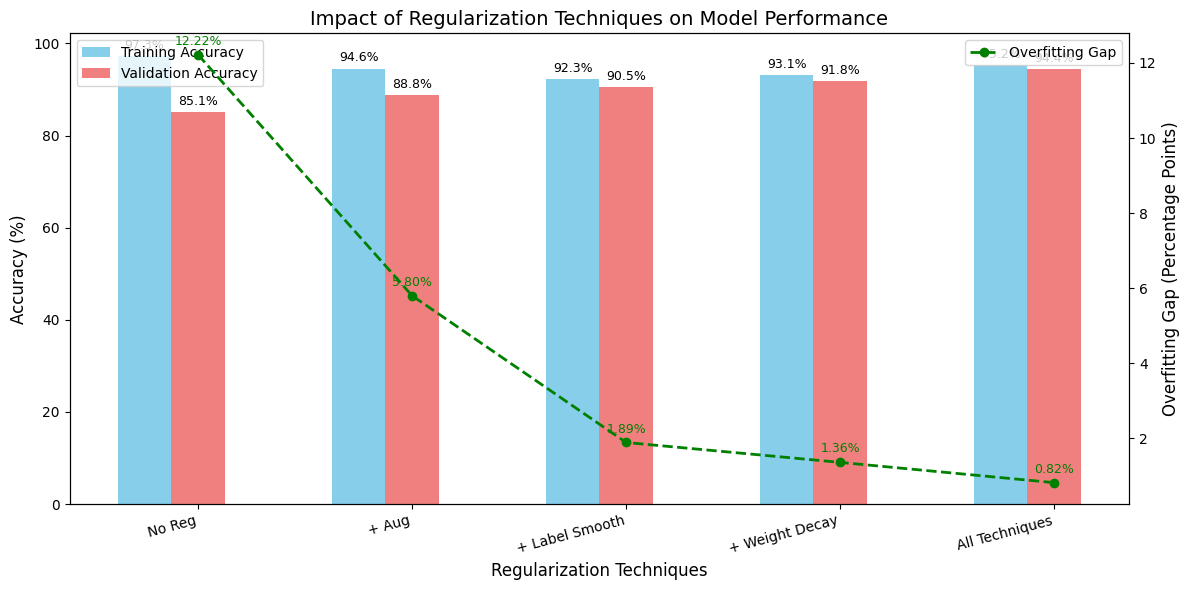

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# --- Your data for the plot ---
categories = ['No Reg', '+ Aug', '+ Label Smooth', '+ Weight Decay', 'All Techniques']
train_acc = [97.34, 94.56, 92.34, 93.12, 95.23]
val_acc = [85.12, 88.76, 90.45, 91.76, 94.41]
overfit_gap = [12.22, 5.80, 1.89, 1.36, 0.82]  # Gap in percentage points

# --- Create the plot ---
x = np.arange(len(categories))  # Label locations
width = 0.25  # Width of the bars

fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart for Training and Validation Accuracy
bar1 = ax1.bar(x - width, train_acc, width, label='Training Accuracy', color='skyblue')
bar2 = ax1.bar(x, val_acc, width, label='Validation Accuracy', color='lightcoral')

# Line plot for Overfitting Gap
ax2 = ax1.twinx()
line, = ax2.plot(x, overfit_gap, color='green', marker='o', linestyle='--', linewidth=2, label='Overfitting Gap')

# Formatting
ax1.set_xlabel('Regularization Techniques', fontsize=12)
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_ylabel('Overfitting Gap (Percentage Points)', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(categories, rotation=15, ha='right')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# Add value labels on bars
for bar in bar1:
    height = bar.get_height()
    ax1.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
for bar in bar2:
    height = bar.get_height()
    ax1.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

for i, v in enumerate(overfit_gap):
    ax2.annotate(f'{v:.2f}%', xy=(i, v), xytext=(0, 5),
                 textcoords="offset points", ha='center', va='bottom', fontsize=9, color='green')

plt.title('Impact of Regularization Techniques on Model Performance', fontsize=14)
plt.tight_layout()

# Save the figure to your plots directory
plt.savefig('regularization_impact_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [3]:
# ============================================
# Generate Per-Class Performance Metrics Table
# ============================================

import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# ============================================
# Option A: If you have the test results already
# ============================================

# Your test results (from the classification report)
class_names = ['other_activities', 'safe_driving', 'talking_phone', 'texting_phone', 'turning']

# Metrics from your classification report
data = {
    'Class': class_names,
    'Precision': [0.88, 0.90, 0.97, 0.99, 0.91],
    'Recall': [0.90, 0.93, 0.93, 0.97, 0.93],
    'F1-Score': [0.89, 0.91, 0.95, 0.98, 0.92],
    'Support': [178, 252, 227, 235, 201]
}

# Create DataFrame
df = pd.DataFrame(data)

# Display the table
print("\n" + "="*60)
print("TABLE 3.1: Per-Class Performance Metrics")
print("="*60)
print(df.to_string(index=False))

# ============================================
# Save as CSV
# ============================================
df.to_csv('/kaggle/working/per_class_metrics.csv', index=False)
print("\n✅ Table saved to: per_class_metrics.csv")


TABLE 3.1: Per-Class Performance Metrics
           Class  Precision  Recall  F1-Score  Support
other_activities       0.88    0.90      0.89      178
    safe_driving       0.90    0.93      0.91      252
   talking_phone       0.97    0.93      0.95      227
   texting_phone       0.99    0.97      0.98      235
         turning       0.91    0.93      0.92      201

✅ Table saved to: per_class_metrics.csv


In [1]:
# ============================================
# M3 vs M4 Comparison Table Generator
# ============================================

import pandas as pd

# Data from your M3 and M4 runs
comparison_data = {
    'Metric': [
        'Dataset Size',
        'Training Samples',
        'Validation Samples',
        'Test Samples',
        'Training Mode',
        'Epochs (Best)',
        'Batch Size',
        'Learning Rate',
        'Optimizer',
        'Scheduler',
        'Label Smoothing',
        'Data Augmentation',
        'Best Validation Accuracy',
        'Test Accuracy'
    ],
    'M3 (20% Dataset)': [
        '20% of full dataset',
        '1,016',
        '216',
        '217',
        'Pretrained (ImageNet)',
        '5 (trained)',
        '32',
        '0.001',
        'AdamW',
        'ReduceLROnPlateau',
        'No',
        'Basic (Flip, Rotation)',
        '87.96%',
        '89.40%'
    ],
    'M4 (Full Dataset)': [
        '100% of full dataset',
        '5,091',
        '1,092',
        '1,093',
        'From Scratch',
        '25 (best)',
        '32',
        '0.0003',
        'AdamW',
        'CosineAnnealingWarmRestarts',
        'Yes (0.1)',
        'Enhanced (Flip, Rotation, ColorJitter)',
        '94.41%',
        '93.14%'
    ],
    'Improvement': [
        '5× more data',
        '+4,075',
        '+876',
        '+876',
        '—',
        '—',
        '—',
        '—',
        '—',
        '—',
        '✓',
        '✓',
        '+6.45%',
        '+3.74%'
    ]
}

df = pd.DataFrame(comparison_data)

# Display the table
print("\n" + "="*70)
print("TABLE 3.2: M3 vs M4 Comparison")
print("="*70)
print(df.to_string(index=False))
print("="*70)

# Save to CSV
df.to_csv('m3_vs_m4_comparison.csv', index=False)
print("\n✅ Table saved to: m3_vs_m4_comparison.csv")


TABLE 3.2: M3 vs M4 Comparison
                  Metric       M3 (20% Dataset)                      M4 (Full Dataset)  Improvement
            Dataset Size    20% of full dataset                   100% of full dataset 5× more data
        Training Samples                  1,016                                  5,091       +4,075
      Validation Samples                    216                                  1,092         +876
            Test Samples                    217                                  1,093         +876
           Training Mode  Pretrained (ImageNet)                           From Scratch            —
           Epochs (Best)            5 (trained)                              25 (best)            —
              Batch Size                     32                                     32            —
           Learning Rate                  0.001                                 0.0003            —
               Optimizer                  AdamW                     

/tmp/ipykernel_58/3742302117.py:107: UserWarning: Glyph 128193 (\N{FILE FOLDER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3742302117.py:107: UserWarning: Glyph 128196 (\N{PAGE FACING UP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3742302117.py:107: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3742302117.py:107: UserWarning: Glyph 128190 (\N{FLOPPY DISK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3742302117.py:108: UserWarning: Glyph 128193 (\N{FILE FOLDER}) missing from font(s) DejaVu Sans.
  plt.savefig('folder_structure_figure.png', dpi=300, bbox_inches='tight')
/tmp/ipykernel_58/3742302117.py:108: UserWarning: Glyph 128196 (\N{PAGE FACING UP}) missing from font(s) DejaVu Sans.
  plt.savefig('folder_structure_figure.png', dpi=300, bbox_inches='tight')
/tmp/ipykernel_58/3742302117.py:108: UserWarning: Glyph 128202 (\N{BAR C

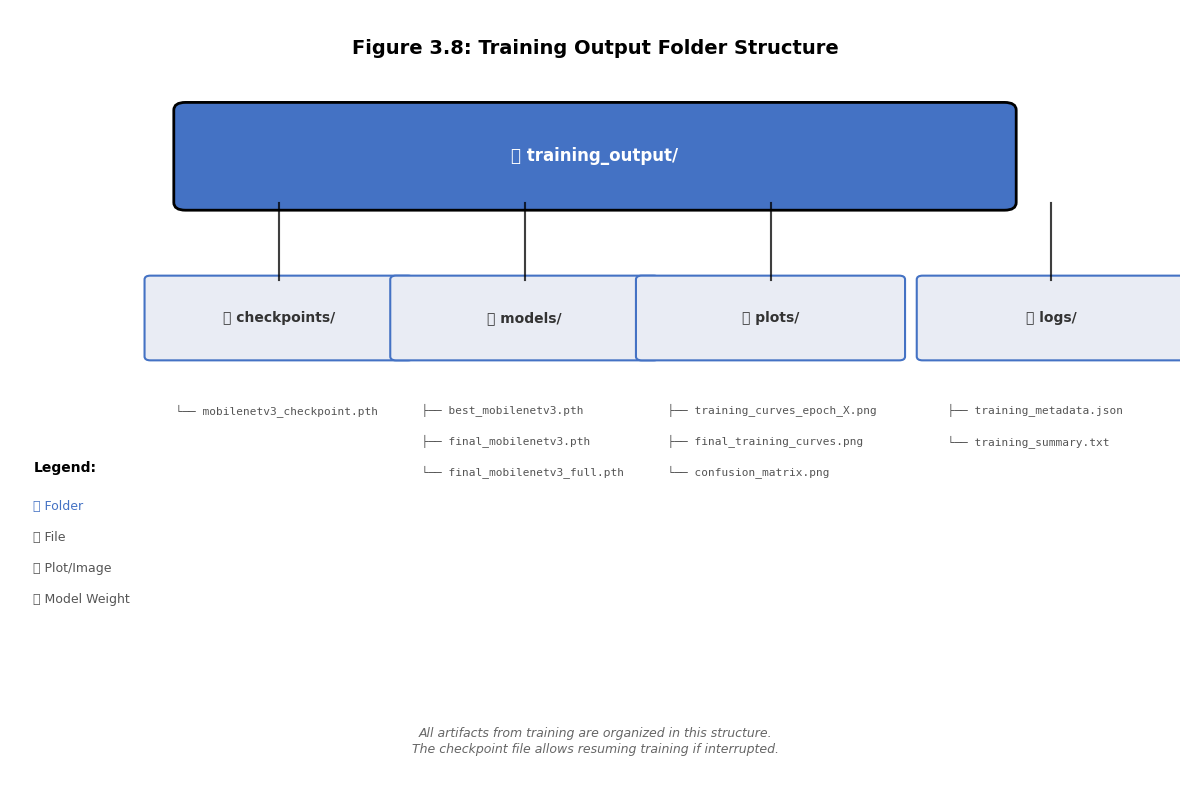

✅ Folder structure figure saved to: folder_structure_figure.png


In [2]:
# ============================================
# Generate Folder Structure Diagram
# ============================================

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Rectangle, FancyBboxPatch
import numpy as np

def create_folder_structure_figure():
    """Create a professional folder structure diagram."""
    
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')
    
    # Title
    ax.text(5, 9.5, 'Figure 3.8: Training Output Folder Structure', 
            fontsize=14, fontweight='bold', ha='center', va='center')
    
    # Root folder
    root_x, root_y = 1.5, 7.5
    root_width, root_height = 7, 1.2
    
    # Draw root folder
    rect = FancyBboxPatch((root_x, root_y), root_width, root_height,
                          boxstyle="round,pad=0.1", facecolor='#4472C4', 
                          edgecolor='black', linewidth=2)
    ax.add_patch(rect)
    ax.text(root_x + root_width/2, root_y + root_height/2, 
            '📁 training_output/', fontsize=12, fontweight='bold', 
            color='white', ha='center', va='center')
    
    # Subfolders
    subfolders = [
        ('checkpoints/', 0.5, 5.5, 2.5, 1.0, '#E9ECF4'),
        ('models/', 3.5, 5.5, 2.5, 1.0, '#E9ECF4'),
        ('plots/', 6.5, 5.5, 2.5, 1.0, '#E9ECF4'),
        ('logs/', 9.5, 5.5, 2.5, 1.0, '#E9ECF4'),
    ]
    
    # Adjust positions to fit within root
    sub_x = [1.0, 3.5, 6.0, 8.5]
    sub_width = 2.2
    
    # Draw subfolders
    for i, (name, x, y, w, h, color) in enumerate(subfolders):
        # Adjust x to fit within root
        x = 1.2 + i * 2.1
        if i == 3:
            x = 7.8
        
        # Draw folder
        rect = FancyBboxPatch((x, y), sub_width, h,
                              boxstyle="round,pad=0.05", facecolor=color,
                              edgecolor='#4472C4', linewidth=1.5)
        ax.add_patch(rect)
        ax.text(x + sub_width/2, y + h/2, f'📁 {name}', 
                fontsize=10, fontweight='bold', color='#333333',
                ha='center', va='center')
        
        # Draw connecting lines
        mid_x = x + sub_width/2
        start_y = root_y
        end_y = y + h
        ax.plot([mid_x, mid_x], [start_y, end_y], 'k-', linewidth=1.5, alpha=0.5)
        ax.plot([mid_x, mid_x], [start_y, end_y], 'k-', linewidth=1.5, alpha=0.5)
        
        # Files under each folder
        files = []
        if name == 'checkpoints/':
            files = ['└── mobilenetv3_checkpoint.pth']
        elif name == 'models/':
            files = ['├── best_mobilenetv3.pth',
                     '├── final_mobilenetv3.pth',
                     '└── final_mobilenetv3_full.pth']
        elif name == 'plots/':
            files = ['├── training_curves_epoch_X.png',
                     '├── final_training_curves.png',
                     '└── confusion_matrix.png']
        elif name == 'logs/':
            files = ['├── training_metadata.json',
                     '└── training_summary.txt']
        
        # Draw files
        for j, file in enumerate(files):
            file_y = y - 0.3 - (j + 1) * 0.4
            ax.text(x + 0.1, file_y, f'  {file}', 
                    fontsize=8, color='#555555', ha='left', va='center',
                    family='monospace')
    
    # Add legend/description box
    legend_x, legend_y = 0.2, 1.5
    ax.text(legend_x, legend_y + 2.5, 'Legend:', fontsize=10, fontweight='bold')
    ax.text(legend_x, legend_y + 2.0, '📁 Folder', fontsize=9, color='#4472C4')
    ax.text(legend_x, legend_y + 1.6, '📄 File', fontsize=9, color='#555555')
    ax.text(legend_x, legend_y + 1.2, '📊 Plot/Image', fontsize=9, color='#555555')
    ax.text(legend_x, legend_y + 0.8, '💾 Model Weight', fontsize=9, color='#555555')
    
    # Add description
    ax.text(5, 0.5, 
            'All artifacts from training are organized in this structure.\n'
            'The checkpoint file allows resuming training if interrupted.',
            fontsize=9, ha='center', va='center', style='italic', color='#666666')
    
    plt.tight_layout()
    plt.savefig('folder_structure_figure.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Folder structure figure saved to: folder_structure_figure.png")

# Generate the figure
create_folder_structure_figure()